# Arbitrary Entangled State Using RY and CNOT Gates

## 1. Objective
The objective of this experiment is to generate a controllable, arbitrary two-qubit entangled state using a parameterized Pauli-Y rotation ($R_Y$) gate followed by a Controlled-NOT (CNOT) gate, and to verify the resulting amplitudes and state probabilities using exact quantum statevector simulation.

---

## 2. Theory

### Pauli-Y Rotation Gate ($R_Y$)
The single-qubit $R_Y(\theta)$ gate executes a continuous rotation of the quantum state vector by an angle $\theta$ around the Y-axis of the Bloch sphere. In matrix form:

$$R_Y(\theta) = \exp\left(-i\frac{\theta}{2} Y\right) = \begin{pmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{pmatrix}$$

Applying $R_Y(\theta)$ to the ground state $|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$ produces a parameterized superposition with purely real probability amplitudes:

$$R_Y(\theta)|0\rangle = \cos\left(\frac{\theta}{2}\right)|0\rangle + \sin\left(\frac{\theta}{2}\right)|1\rangle$$

### Entanglement Generation via CNOT
When applied to a 2-qubit register initialized to $|00\rangle$, rotating the first qubit yields the separable state:

$$|\psi_1\rangle = (R_Y(\theta) \otimes I)|00\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|10\rangle$$

Applying a CNOT gate with qubit 0 as control and qubit 1 as target conditionally flips qubit 1 whenever qubit 0 is in state $|1\rangle$:
- $|00\rangle \xrightarrow{\quad CX \quad} |00\rangle$
- $|10\rangle \xrightarrow{\quad CX \quad} |11\rangle$

This yields the parameterized entangled state:

$$|\psi_2\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|11\rangle$$

By varying $\theta \in [0, 2\pi]$, this circuit synthesizes arbitrary entangled states. When $\theta = \frac{\pi}{2}$, the state reduces to the maximally entangled Bell state $|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$.

### Theoretical Probabilities for $\theta = \frac{\pi}{3}$
In this experiment, the rotation angle is configured to $\theta = \frac{\pi}{3}$ ($60^\circ$), giving a half-angle of $\frac{\theta}{2} = \frac{\pi}{6}$ ($30^\circ$):

- **Amplitude of $|00\rangle$**:
  $$\cos\left(\frac{\pi}{6}\right) = \frac{\sqrt{3}}{2} \approx 0.8660254$$
- **Amplitude of $|11\rangle$**:
  $$\sin\left(\frac{\pi}{6}\right) = \frac{1}{2} = 0.5000000$$
- **Probability of $|00\rangle$**:
  $$P(|00\rangle) = \cos^2\left(\frac{\pi}{6}\right) = \left(\frac{\sqrt{3}}{2}\right)^2 = \frac{3}{4} = 0.75$$
- **Probability of $|11\rangle$**:
  $$P(|11\rangle) = \sin^2\left(\frac{\pi}{6}\right) = \left(\frac{1}{2}\right)^2 = \frac{1}{4} = 0.25$$
- **Probabilities of $|01\rangle$ and $|10\rangle$**:
  $$P(|01\rangle) = P(|10\rangle) = 0.00$$

## 3. Circuit Explanation
The circuit operates on a 2-qubit register:

1. **Parameter Setup**:
   - `theta = np.pi / 3`: Defines the rotation angle.
2. **$R_Y$ Gate (`qc.ry(theta, 0)`)**:
   - Applied to qubit 0 to set the exact amplitude ratio $\cos(\pi/6) : \sin(\pi/6)$.
3. **CNOT Gate (`qc.cx(0, 1)`)**:
   - Uses qubit 0 as control and qubit 1 as target to introduce non-local quantum correlation between the two qubits.
4. **Statevector Verification**:
   - Evaluated using Qiskit's `Statevector.from_instruction(qc)`, allowing direct inspection of exact probability amplitudes and state probabilities without sampling noise.

/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2603/3294457629.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit


Arbitrary Entangled State Circuit
     ┌─────────┐     
q_0: ┤ Ry(π/3) ├──■──
     └─────────┘┌─┴─┐
q_1: ───────────┤ X ├
                └───┘

Statevector:
Statevector([0.8660254+0.j, 0.       +0.j, 0.       +0.j, 0.5      +0.j],
            dims=(2, 2))

Amplitudes:
00 = 0.866025
01 = 0.000000
10 = 0.000000
11 = 0.500000

Probabilities:
00 = 0.750000
01 = 0.000000
10 = 0.000000
11 = 0.250000


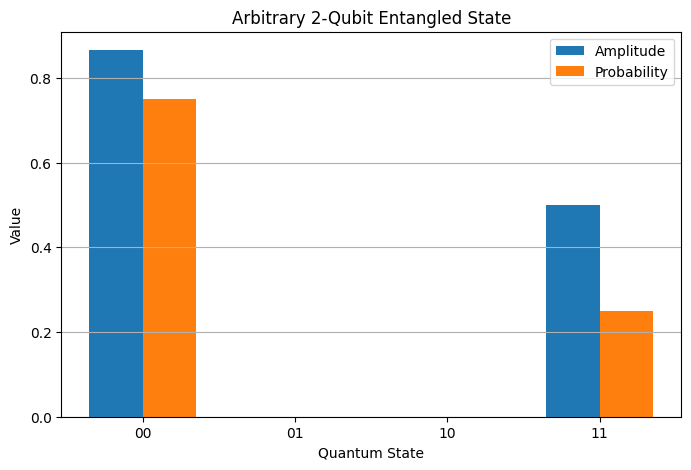


SUCCESS!
Arbitrary entangled state verified.


In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

theta = np.pi / 3

qc = QuantumCircuit(2)

qc.ry(theta, 0)
qc.cx(0, 1)

print("Arbitrary Entangled State Circuit")
print(qc.draw())

state = Statevector.from_instruction(qc)

print("\nStatevector:")
print(state)

states = ['00', '01', '10', '11']

amplitudes = [
    abs(state.data[i])
    for i in range(4)
]

probabilities = [
    abs(state.data[i]) ** 2
    for i in range(4)
]

print("\nAmplitudes:")

for state_name, amplitude in zip(states, state.data):
    print(
        state_name,
        "=",
        f"{amplitude.real:.6f}"
    )

print("\nProbabilities:")

for state_name, probability in zip(states, probabilities):
    print(
        state_name,
        "=",
        f"{probability:.6f}"
    )

x = np.arange(len(states))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(
    x - width / 2,
    amplitudes,
    width,
    label='Amplitude'
)

plt.bar(
    x + width / 2,
    probabilities,
    width,
    label='Probability'
)

plt.xticks(x, states)
plt.xlabel("Quantum State")
plt.ylabel("Value")
plt.title("Arbitrary 2-Qubit Entangled State")
plt.legend()
plt.grid(axis='y')

plt.show()

expected_00 = np.cos(theta / 2) ** 2
expected_11 = np.sin(theta / 2) ** 2

if (
    np.isclose(probabilities[0], expected_00)
    and
    np.isclose(probabilities[3], expected_11)
    and
    np.isclose(probabilities[1], 0)
    and
    np.isclose(probabilities[2], 0)
):
    print("\nSUCCESS!")
    print("Arbitrary entangled state verified.")
else:
    print("\nVerification failed.")

## 4. Results & Observations

### Observed Circuit and Statevector Output
The execution of the circuit produces the following output:

```
Arbitrary Entangled State Circuit
     ┌─────────┐     
q_0: ┤ Ry(π/3) ├──■──
     └─────────┘┌─┴─┐
q_1: ───────────┤ X ├
                └───┘

Statevector:
Statevector([0.8660254+0.j, 0.       +0.j, 0.       +0.j, 0.5      +0.j],
            dims=(2, 2))
```

### Amplitudes and Probabilities
The computed computational-basis amplitudes and corresponding state probabilities are:

| Basis State | Theoretical Amplitude | Observed Amplitude | Theoretical Probability | Observed Probability |
|:-----------:|:---------------------:|:------------------:|:-----------------------:|:--------------------:|
| $|00\rangle$ | $\frac{\sqrt{3}}{2} \approx 0.866025$ | **0.866025** | $\cos^2(\pi/6) = 0.750000$ | **0.750000** |
| $|01\rangle$ | $0.000000$ | **0.000000** | $0.000000$ | **0.000000** |
| $|10\rangle$ | $0.000000$ | **0.000000** | $0.000000$ | **0.000000** |
| $|11\rangle$ | $\frac{1}{2} = 0.500000$ | **0.500000** | $\sin^2(\pi/6) = 0.250000$ | **0.250000** |

### Key Findings
- **Probability Ratio**: The probability of finding the system in $|00\rangle$ is exactly $0.75$ ($75\%$) and $|11\rangle$ is $0.25$ ($25\%$), in exact agreement with the theoretical values for $\theta = \frac{\pi}{3}$.
- **Absence of Anti-Correlated States**: States $|01\rangle$ and $|10\rangle$ have zero probability, proving that the two qubits remain strictly correlated despite having asymmetric weights.
- **Automated Validation**: The programmatic verification logic confirmed:
  ```
  SUCCESS!
  Arbitrary entangled state verified.
  ```

## 5. Conclusion
This experiment demonstrates how a parameterized single-qubit rotation ($R_Y$) combined with an entangling gate (CNOT) generates arbitrary two-qubit entangled states:

$$|\psi\rangle = \cos\left(\frac{\theta}{2}\right)|00\rangle + \sin\left(\frac{\theta}{2}\right)|11\rangle$$

Key takeaways:
1. **Controllable Amplitudes**: The rotation angle $\theta$ provides continuous tuning of the probability distribution between $|00\rangle$ and $|11\rangle$ without altering the entanglement structure.
2. **Deterministic Correlation**: The CNOT gate transfers the superposition on the control qubit into strict correlation with the target qubit, ensuring zero probability for $|01\rangle$ and $|10\rangle$.
3. **Exact Statevector Verification**: Statevector analysis confirms exact analytical alignment with quantum theoretical predictions for $\theta = \frac{\pi}{3}$ ($P(|00\rangle) = 0.75$, $P(|11\rangle) = 0.25$).